In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# ==========================================
# 1. CARGA Y PREPARACIÓN EN SERIE TEMPORAL
# ==========================================
ruta_archivo = "/content/historial_cambios (3).csv"

try:
    df = pd.read_csv(ruta_archivo)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo.")
    exit()

# SOLUCIÓN AL FORMATO: Forzar el parseo correcto de tu formato "23/2/2026, 2:34:58 p.m"
if df['fecha_modificacion'].dtype == 'object':
    df['fecha_modificacion'] = df['fecha_modificacion'].str.replace('.', '', regex=False).str.upper()

df['fecha_modificacion'] = pd.to_datetime(df['fecha_modificacion'], format='%d/%m/%Y, %I:%M:%S %p', errors='coerce')

# Si algunas filas fallan por otro formato, usamos mixed como respaldo
en_blanco = df['fecha_modificacion'].isna()
if en_blanco.any():
    df.loc[en_blanco, 'fecha_modificacion'] = pd.to_datetime(df.loc[en_blanco, 'fecha_modificacion'], format='mixed', errors='coerce')

df = df.dropna(subset=['fecha_modificacion'])

# Extraer solo la fecha (sin hora) para agrupar por día
df['fecha'] = df['fecha_modificacion'].dt.date

# Crear la serie temporal: Contar cuántas tareas se hacen por día
serie_temporal = df.groupby('fecha').size().reset_index(name='total_tareas')

# Asegurar que la fecha sea tipo datetime antes de ordenar
serie_temporal['fecha'] = pd.to_datetime(serie_temporal['fecha'])
serie_temporal = serie_temporal.sort_values('fecha').reset_index(drop=True)



In [16]:
# ==========================================
# 2. CREACIÓN DE CARACTERÍSTICAS (Feature Engineering)
# ==========================================
serie_temporal['dia_semana'] = serie_temporal['fecha'].dt.dayofweek
serie_temporal['dia_mes'] = serie_temporal['fecha'].dt.day

serie_temporal['es_sabado'] = (serie_temporal['dia_semana'] == 5).astype(int)
serie_temporal['es_domingo'] = (serie_temporal['dia_semana'] == 6).astype(int)

# "Lag Features" + "Rolling Window" (Media móvil para evitar el estancamiento en cero)
serie_temporal['tareas_ayer'] = serie_temporal['total_tareas'].shift(1)
serie_temporal['media_movil_3d'] = serie_temporal['total_tareas'].shift(1).rolling(window=3).mean()

# Eliminamos filas con NaN resultantes del desfase (shift y rolling)
serie_temporal = serie_temporal.dropna().reset_index(drop=True)

X = serie_temporal[['dia_semana', 'dia_mes', 'es_sabado', 'es_domingo', 'tareas_ayer', 'media_movil_3d']]
y = serie_temporal['total_tareas']
# Función nativa para calcular el wMAPE (Weighted MAPE)
def calcular_wmape(y_real, y_pred):
    sum_real = np.sum(y_real)
    if sum_real == 0:
        return 0.0
    return np.sum(np.abs(y_real - y_pred)) / sum_real

# ==========================================
# 2.5 EVALUACIÓN ESTRICTA (División Temporal)
# ==========================================
dias_test = 7

if len(serie_temporal) > dias_test * 2:
    X_train, X_test = X.iloc[:-dias_test], X.iloc[-dias_test:]
    y_train, y_test = y.iloc[:-dias_test], y.iloc[-dias_test:]

    modelo_evaluacion = LinearRegression()
    modelo_evaluacion.fit(X_train, y_train)
    y_pred_test = np.clip(modelo_evaluacion.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    wmape = calcular_wmape(y_test, y_pred_test)
    precision_ajustada = max(0, 100 - (wmape * 100))

    serie_temporal.loc[serie_temporal.index[-dias_test:], 'prediccion_test'] = y_pred_test
else:
    print("⚠️ Datos insuficientes para realizar una validación temporal estricta.")
    mae, rmse, wmape, precision_ajustada = None, None, None, None



In [17]:
# ==========================================
# 3. ENTRENAMIENTO DEL MODELO DE PRONÓSTICO (Producción)
# ==========================================
modelo_futuro = LinearRegression()
modelo_futuro.fit(X, y)



LinearRegression()

In [18]:
# ==========================================
# 4. PREDICCIÓN DE LOS PRÓXIMOS 7 DÍAS (Proyección Dinámica)
# ==========================================
ultima_fecha = serie_temporal['fecha'].max()

# Necesitamos mantener un registro de los últimos valores reales para calcular las variables dinámicamente
historial_valores = list(serie_temporal['total_tareas'].iloc[-3:])

futuras_fechas = []
predicciones_futuras = []

for i in range(1, 12):
    nueva_fecha = ultima_fecha + pd.Timedelta(days=i)
    n_dia_semana = nueva_fecha.dayofweek
    n_dia_mes = nueva_fecha.day

    n_es_sabado = 1 if n_dia_semana == 5 else 0
    n_es_domingo = 1 if n_dia_semana == 6 else 0

    # Extraer las características basadas en la ventana móvil simulada
    lag_1 = historial_valores[-1]
    movil_3d = np.mean(historial_valores[-3:])

    entrada_prediccion = pd.DataFrame([{
        'dia_semana': n_dia_semana,
        'dia_mes': n_dia_mes,
        'es_sabado': n_es_sabado,
        'es_domingo': n_es_domingo,
        'tareas_ayer': lag_1,
        'media_movil_3d': movil_3d
    }])

    # Predecir de forma recursiva
    prediccion = max(0, int(modelo_futuro.predict(entrada_prediccion)[0]))

    futuras_fechas.append(nueva_fecha)
    predicciones_futuras.append(prediccion)

    # Actualizar el historial para la predicción del día siguiente
    historial_valores.append(prediccion)

df_futuro = pd.DataFrame({'fecha': futuras_fechas, 'pronostico': predicciones_futuras})

# Imprimir reporte de calificación corregido
print("\n📊 REPORTE DE CALIFICACIÓN DEL MODELO (Últimos 7 días históricos):")
print("-" * 65)
if mae is not None:
    print(f"• Error Absoluto Medio (MAE):         {mae:.2f} tareas")
    print(f"• Raíz del Error Cuadrático (RMSE):   {rmse:.2f} tareas")
    print(f"• Error Porcentual Ponderado (wMAPE): {wmape * 100:.2f}%")
    print(f"• Precisión General Ajustada:         {precision_ajustada:.2f}%")
else:
    print("No se pudo calcular por falta de histórico suficiente.")
print("-" * 65)

print("\n📈 PRONÓSTICO DE CARGA DE TRABAJO (PRÓXIMOS 7 DÍAS REALES):")
for f, p in zip(futuras_fechas, predicciones_futuras):
    print(f"Fecha: {f.strftime('%Y-%m-%d')} -> Tareas estimadas: {p}")




📊 REPORTE DE CALIFICACIÓN DEL MODELO (Últimos 7 días históricos):
-----------------------------------------------------------------
• Error Absoluto Medio (MAE):         15.28 tareas
• Raíz del Error Cuadrático (RMSE):   20.06 tareas
• Error Porcentual Ponderado (wMAPE): 72.29%
• Precisión General Ajustada:         27.71%
-----------------------------------------------------------------

📈 PRONÓSTICO DE CARGA DE TRABAJO (PRÓXIMOS 7 DÍAS REALES):
Fecha: 2026-05-28 -> Tareas estimadas: 9
Fecha: 2026-05-29 -> Tareas estimadas: 2
Fecha: 2026-05-30 -> Tareas estimadas: 0
Fecha: 2026-05-31 -> Tareas estimadas: 0
Fecha: 2026-06-01 -> Tareas estimadas: 46
Fecha: 2026-06-02 -> Tareas estimadas: 40
Fecha: 2026-06-03 -> Tareas estimadas: 37
Fecha: 2026-06-04 -> Tareas estimadas: 33
Fecha: 2026-06-05 -> Tareas estimadas: 27
Fecha: 2026-06-06 -> Tareas estimadas: 13
Fecha: 2026-06-07 -> Tareas estimadas: 6


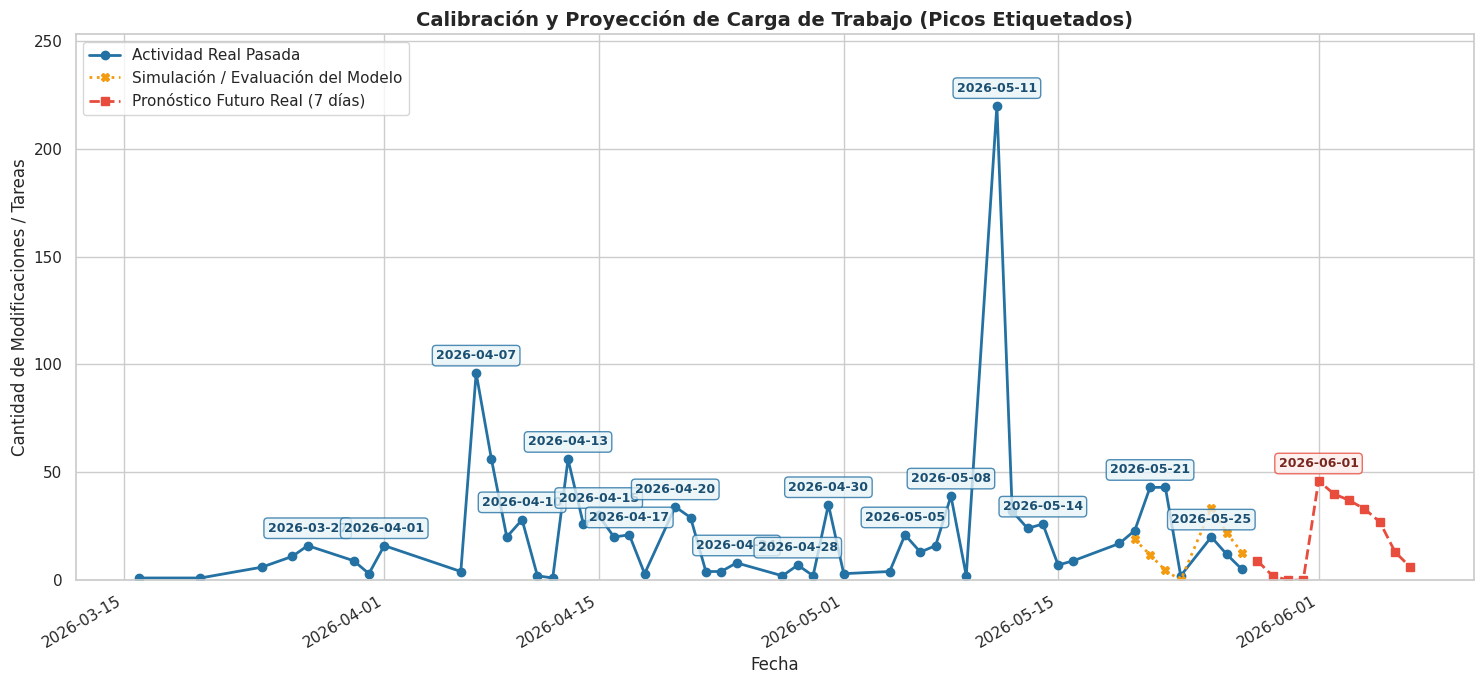

In [19]:
# ==========================================
# 5. GRÁFICA DE TENDENCIA, VALIDACIÓN Y PRONÓSTICO (CON ETIQUETAS EN PICOS)
# ==========================================
from scipy.signal import find_peaks  # Importación necesaria para detectar picos

plt.figure(figsize=(15, 7))
sns.set_theme(style="whitegrid")

# 1. Datos históricos reales
plt.plot(serie_temporal['fecha'], serie_temporal['total_tareas'], label='Actividad Real Pasada', color='#2471a3', marker='o', linewidth=2)

# 2. El comportamiento del modelo en el set de pruebas (Test)
if mae is not None:
    df_test_plot = serie_temporal.dropna(subset=['prediccion_test'])
    plt.plot(df_test_plot['fecha'], df_test_plot['prediccion_test'], label='Simulación / Evaluación del Modelo', color='#f39c12', linestyle=':', marker='X', linewidth=2)

# 3. Línea del pronóstico futuro real
plt.plot(df_futuro['fecha'], df_futuro['pronostico'], label='Pronóstico Futuro Real (7 días)', color='#e74c3c', linestyle='--', marker='s', linewidth=2)

# ------------------------------------------
# DETECCIÓN Y ETIQUETADO DE PICOS
# ------------------------------------------
# Picos en el Histórico Real (ajusta 'distance' si hay demasiados picos juntos)
picos_hist, _ = find_peaks(serie_temporal['total_tareas'], distance=2, prominence=1)

for idx in picos_hist:
    fecha_pico = serie_temporal['fecha'].iloc[idx]
    valor_pico = serie_temporal['total_tareas'].iloc[idx]

    plt.annotate(
        fecha_pico.strftime('%Y-%m-%d'),
        xy=(fecha_pico, valor_pico),
        xytext=(0, 10),  # Desplazamiento de 10 puntos arriba del punto
        textcoords='offset points',
        ha='center',
        fontsize=9,
        weight='bold',
        color='#1b4f72',
        bbox=dict(boxstyle="round,pad=0.3", fc="#e8f4f8", ec="#2471a3", lw=1, alpha=0.8)
    )

# Picos en el Pronóstico Futuro
picos_fut, _ = find_peaks(df_futuro['pronostico'], distance=1)

for idx in picos_fut:
    fecha_pico = df_futuro['fecha'].iloc[idx]
    valor_pico = df_futuro['pronostico'].iloc[idx]

    plt.annotate(
        fecha_pico.strftime('%Y-%m-%d'),
        xy=(fecha_pico, valor_pico),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        weight='bold',
        color='#78281f',
        bbox=dict(boxstyle="round,pad=0.3", fc="#fdedec", ec="#e74c3c", lw=1, alpha=0.8)
    )
# ------------------------------------------

# Configuración visual optimizada
plt.title('Calibración y Proyección de Carga de Trabajo (Picos Etiquetados)', fontsize=14, weight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Modificaciones / Tareas', fontsize=12)

# Ajustar los límites del eje Y para que las etiquetas de los picos más altos no se corten
plt.ylim(0, max(serie_temporal['total_tareas'].max(), df_futuro['pronostico'].max()) * 1.15)

plt.gcf().autofmt_xdate()
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()